# Repetition Error Analysis
We will see what input components that might lead to the repetition error.
- Analyze which modifiers fail most? ("twice" vs "thrice"?)
- Is it semantic (understanding count) or syntactic (generating repetitions)?

In [130]:
import pandas as pd

In [131]:
split_errors_df = pd.read_csv('../results/error_breakdown/compositional_analysis/merged_errors.csv')
repetition_errors = split_errors_df[split_errors_df['error_type'] == 'REPETITION']
repetition_errors.to_csv('../results/error_breakdown/compositional_analysis/repetition_error.csv', index=False)

In [132]:
from collections import defaultdict

# Analyze by modifier type
modifier_analysis = defaultdict(lambda: {'count': 0, 'examples': []})

for _, row in repetition_errors.iterrows():
    input_text = row['input']
    
    # Extract modifiers
    modifiers = []
    if 'twice' in input_text:
        modifiers.append('twice')
    if 'thrice' in input_text:
        modifiers.append('thrice')
    if 'four times' in input_text or 'around' in input_text: # turn around implies four times
        modifiers.append('four_times')
    
    for mod in modifiers or ['unknown']:
        modifier_analysis[mod]['count'] += 1
        if len(modifier_analysis[mod]['examples']) < 3:
            modifier_analysis[mod]['examples'].append({
                'input': row['input'],
                'target': row['target'],
                'pred': row['prediction']
            })

for mod, stats in modifier_analysis.items():
    print(f"\n{mod.upper()}: {stats['count']} errors")
    for ex in stats['examples']:
        print(f"  Input: {ex['input']}")
        print(f"  Target:{ex['target']}")
        print(f"  Pred:  {ex['pred']}")


FOUR_TIMES: 156 errors
  Input: turn left and run around right
  Target:I_TURN_LEFT I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN
  Pred:  I_TURN_LEFT I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_
  Input: turn around left and turn left twice
  Target:I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT
  Pred:  I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT
  Input: turn around left
  Target:I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT
  Pred:  I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT

TWICE: 91 errors
  Input: run twice and turn opposite right thrice
  Target:I_RUN I_RUN I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT
  Pred:  I_RUN I_RUN I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_
  Input: turn around left and turn left twice
  Target:I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_

###  Modifier Co-occurrence Analysis 

Question: Do failures cluster around specific modifiers or combinations?

In [133]:
modifier_df = [
    {'modifier': 'twice', 'error_counts': 0},
    {'modifier': 'thrice', 'error_counts': 0},
    {'modifier': 'four_times', 'error_counts': 0}
]
for _, row in repetition_errors.iterrows():
    input_text = row['input']

    if 'twice' in input_text:
        modifier_df[0]['error_counts'] += 1
    if 'thrice' in input_text:
        modifier_df[1]['error_counts'] += 1
    if 'four times' in input_text or 'around' in input_text: # turn around implies four times
        modifier_df[2]['error_counts'] += 1

modifier_df = pd.DataFrame(modifier_df)
modifier_df


,modifier,error_counts
0,twice,91
1,thrice,46
2,four_times,156


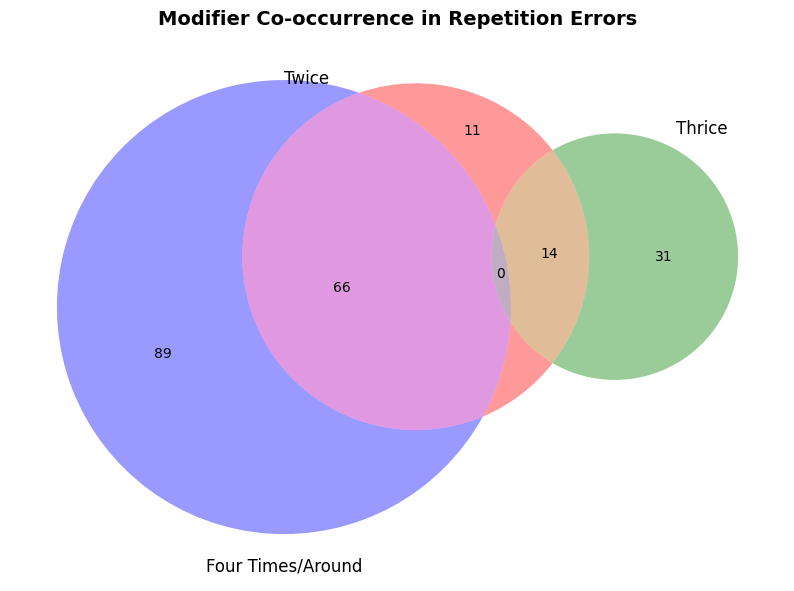

Twice only: 11
Thrice only: 31
Four times only: 89
Twice + Thrice: 14
Twice + Four times: 66
Thrice + Four times: 1
All three: 0


In [134]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Track which examples have which modifiers
twice_errors = set()
thrice_errors = set()
four_times_errors = set()

for idx, row in repetition_errors.iterrows():
    input_text = row['input']
    
    if 'twice' in input_text:
        twice_errors.add(idx)
    if 'thrice' in input_text:
        thrice_errors.add(idx)
    if 'four times' in input_text or 'around' in input_text:
        four_times_errors.add(idx)

# Create Venn diagram
fig, ax = plt.subplots(figsize=(10, 8))
venn3([twice_errors, thrice_errors, four_times_errors], 
      set_labels=('Twice', 'Thrice', 'Four Times/Around'),
      ax=ax)
ax.set_title('Modifier Co-occurrence in Repetition Errors', fontsize=14, fontweight='bold')
plt.savefig('../results/error_breakdown/compositional_analysis/modifier_venn.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print(f"Twice only: {len(twice_errors - thrice_errors - four_times_errors)}")
print(f"Thrice only: {len(thrice_errors - twice_errors - four_times_errors)}")
print(f"Four times only: {len(four_times_errors - twice_errors - thrice_errors)}")
print(f"Twice + Thrice: {len(twice_errors & thrice_errors)}")
print(f"Twice + Four times: {len(twice_errors & four_times_errors)}")
print(f"Thrice + Four times: {len(thrice_errors & four_times_errors)}")
print(f"All three: {len(twice_errors & thrice_errors & four_times_errors)}")

### Semantic Understanding Analysis
Question: Does the model understand WHAT to repeat, but fails to generate the right COUNT?

In [135]:
# Define valid actions
VALID_ACTIONS = {
    'I_RUN', 'I_WALK', 'I_JUMP',
    'I_TURN_LEFT', 'I_TURN_RIGHT',
    'I_LOOK'
}

In [136]:
def analyze_semantic_vs_syntactic(row):
    """
    SEMANTIC ERROR: Model generates wrong actions
    SYNTACTIC ERROR: Model generates right actions but wrong count
    """
    target = row['target'].split()
    pred = row['prediction'].split()
    pred_clean = [token for token in pred if token in VALID_ACTIONS]

    target_actions = set(target)
    pred_actions = set(pred_clean)

    # SYNTACTIC: Same actions but different count
    if target_actions == pred_actions and len(target) != len(pred):
        return 'SYNTACTIC'
    
    # SEMANTIC: Different actions
    elif target_actions != pred_actions:
        return 'SEMANTIC'
    
    else:
        return 'OTHER'

# Apply analysis
repetition_errors['error_category'] = repetition_errors.apply(analyze_semantic_vs_syntactic, axis=1)
error_breakdown = repetition_errors['error_category'].value_counts()
print(error_breakdown)

# Count breakdown
error_breakdown = repetition_errors['error_category'].value_counts()
print("\n" + "="*50)
print("SEMANTIC vs SYNTACTIC BREAKDOWN")
print("="*50)
print(error_breakdown)
print(f"\nSyntactic errors: {error_breakdown.get('SYNTACTIC', 0)} ({error_breakdown.get('SYNTACTIC', 0)/len(repetition_errors)*100:.1f}%)")
print(f"Semantic errors: {error_breakdown.get('SEMANTIC', 0)} ({error_breakdown.get('SEMANTIC', 0)/len(repetition_errors)*100:.1f}%)")


error_category
SYNTACTIC    212
Name: count, dtype: int64

SEMANTIC vs SYNTACTIC BREAKDOWN
error_category
SYNTACTIC    212
Name: count, dtype: int64

Syntactic errors: 212 (100.0%)
Semantic errors: 0 (0.0%)


In [137]:
repetition_semantic_error = repetition_errors[repetition_errors['error_category']=='SEMANTIC']
repetition_semantic_error.to_csv('../results/error_breakdown/compositional_analysis/repetition_semantic_error.csv',index=False)

repetition_syntactic_error = repetition_errors[repetition_errors['error_category']=='SYNTACTIC']
repetition_syntactic_error.to_csv('../results/error_breakdown/compositional_analysis/repetition_syntactic_error.csv')

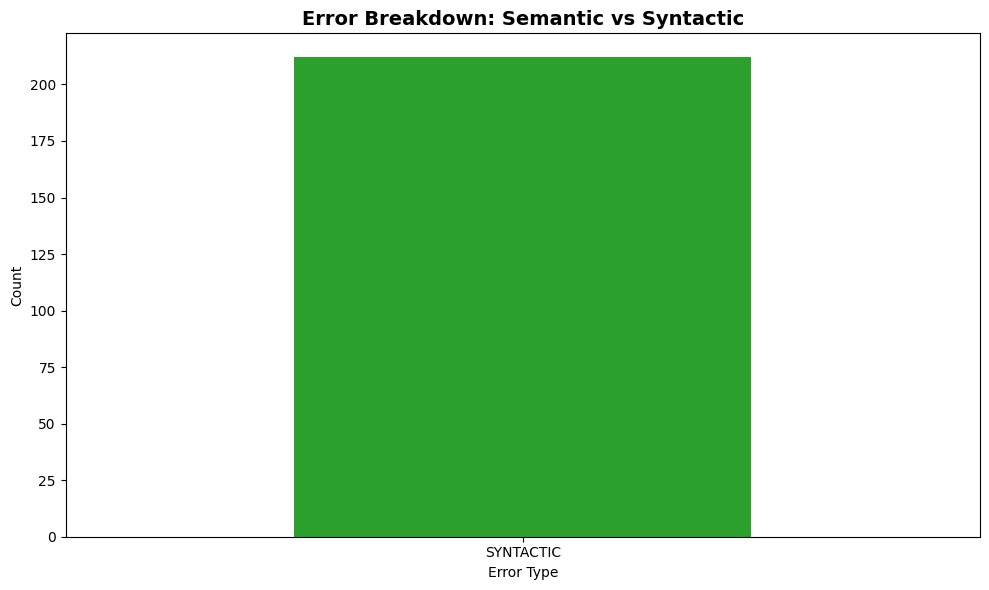

In [138]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
error_breakdown.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728', '#ff7f0e'])
ax.set_title('Error Breakdown: Semantic vs Syntactic', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Error Type')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../results/error_breakdown/compositional_analysis/semantic_syntactic.png', dpi=150, bbox_inches='tight')
plt.show()

### Count Accuracy Analysis
Question: When the model generates repetitions, does it get the RIGHT count?

### Action-Specific Analysis
Question: Do certain actions fail more often with modifiers?

# Synthesis: Why does T5 fail at compositional modifiers?

In [ ]:
# Key Finding: All repetition errors are SYNTACTIC

print("\n" + "="*60)
print("KEY FINDING: Nature of Repetition Errors")
print("="*60)

error_breakdown = repetition_errors['error_category'].value_counts()
print(error_breakdown)

syntactic_count = error_breakdown.get('SYNTACTIC', 0)
semantic_count = error_breakdown.get('SEMANTIC', 0)
total = len(repetition_errors)

print(f"\nSYNTACTIC: {syntactic_count} ({syntactic_count/total*100:.1f}%)")
print(f"SEMANTIC: {semantic_count} ({semantic_count/total*100:.1f}%)")

print("""
INTERPRETATION:
- Model UNDERSTANDS what to repeat (knows I_TURN_RIGHT)
- Model FAILS to generate correct COUNT

Examples:
- "turn around" (should be 4x) → generates 5x I_TURN_RIGHT
- "turn left twice" (should be 2x) → generates 1x I_TURN_LEFT
- Model doesn't map modifiers to counts correctly

ROOT CAUSE:
- Model learned to generate actions but NOT to count/repeat
- Modifiers ("twice", "around") are treated as semantic hints
- But T5 doesn't have explicit mechanism for repetition
- Often generates WRONG COUNT (5x instead of 4x, 3x instead of 2x)

IMPLICATION:
- This is a FUNDAMENTAL ARCHITECTURAL LIMITATION
- T5 is sequence-to-sequence, not count-aware
- Need: Data augmentation OR architectural change for counting
""")


KEY FINDING: Nature of Repetition Errors
error_category
SYNTACTIC    212
Name: count, dtype: int64

SYNTACTIC: 212 (100.0%)
SEMANTIC: 0 (0.0%)

INTERPRETATION:
✓ Model UNDERSTANDS what to repeat (knows I_TURN_RIGHT)
✗ Model FAILS to generate correct COUNT

Examples:
- "turn around" (should be 4x) → generates 5x I_TURN_RIGHT
- "turn left twice" (should be 2x) → generates 1x I_TURN_LEFT
- Model doesn't map modifiers to counts correctly

ROOT CAUSE:
- Model learned to generate actions but NOT to count/repeat
- Modifiers ("twice", "around") are treated as semantic hints
- But T5 doesn't have explicit mechanism for repetition
- Often generates WRONG COUNT (5x instead of 4x, 3x instead of 2x)

IMPLICATION:
→ This is a FUNDAMENTAL ARCHITECTURAL LIMITATION
→ T5 is sequence-to-sequence, not count-aware
→ Need: Data augmentation OR architectural change for counting




COUNT ACCURACY WITHIN SYNTACTIC ERRORS

Target vs Predicted counts:

Target 2x:
  Predicted 4x: 64 times
  Predicted 5x: 11 times
  Predicted 6x: 9 times
  Predicted 2x: 5 times
  Predicted 7x: 1 times
  Predicted 3x: 1 times

Target 3x:
  Predicted 1x: 11 times
  Predicted 7x: 7 times
  Predicted 4x: 6 times
  Predicted 5x: 4 times
  Predicted 3x: 3 times
  Predicted 6x: 1 times

Target 4x:
  Predicted 1x: 48 times
  Predicted 5x: 35 times
  Predicted 2x: 4 times
  Predicted 7x: 1 times
  Predicted 4x: 1 times


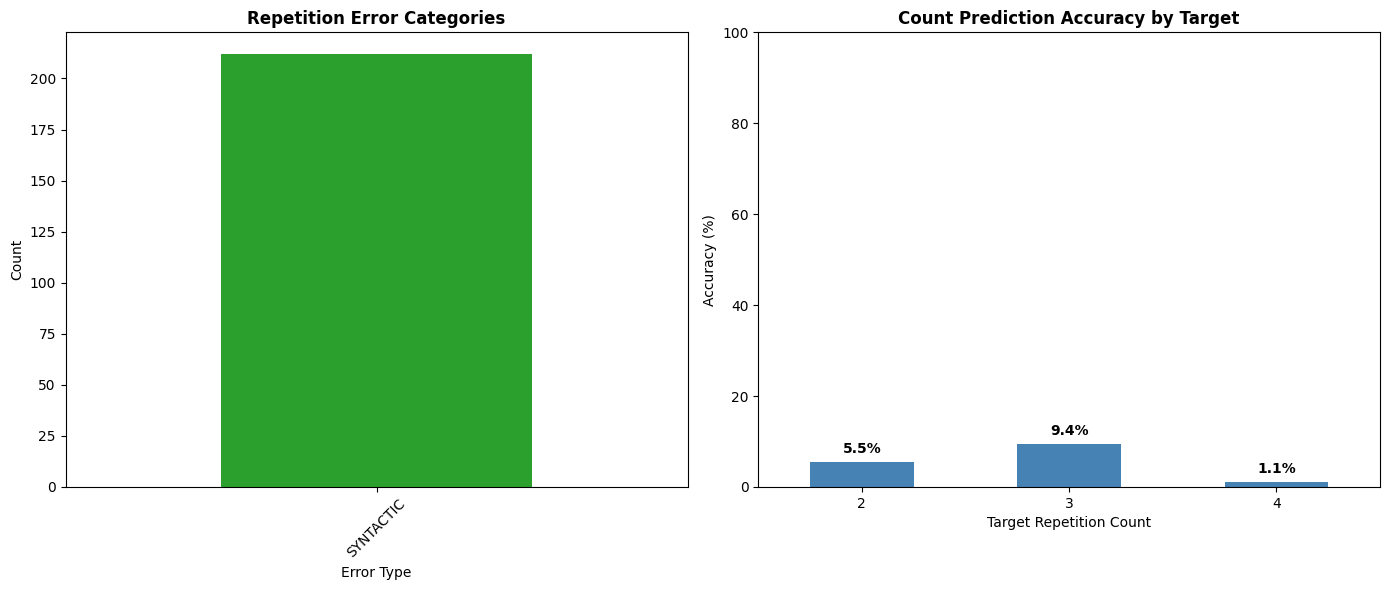

In [148]:
# Analyze count correctness
print("\n" + "="*60)
print("COUNT ACCURACY WITHIN SYNTACTIC ERRORS")
print("="*60)

syntactic_errors = repetition_errors[repetition_errors['error_category'] == 'SYNTACTIC']

def extract_count_from_input(input_text):
    if 'twice' in input_text:
        return 2
    elif 'thrice' in input_text:
        return 3
    elif 'four times' in input_text or 'around' in input_text:
        return 4
    else:
        return 1

def count_action_repetitions(action_sequence):
    actions = action_sequence.split()
    if not actions:
        return 0
    first_action = actions[0]
    return sum(1 for action in actions if action == first_action)

syntactic_errors['target_count'] = syntactic_errors['input'].apply(extract_count_from_input)
syntactic_errors['pred_count'] = syntactic_errors['prediction'].apply(count_action_repetitions)

print(f"\nTarget vs Predicted counts:")
for target_c in sorted(syntactic_errors['target_count'].unique()):
    subset = syntactic_errors[syntactic_errors['target_count'] == target_c]
    pred_counts = subset['pred_count'].value_counts()
    print(f"\nTarget {target_c}x:")
    for pred_c, count in pred_counts.items():
        print(f"  Predicted {pred_c}x: {count} times")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart: Error type breakdown
error_breakdown.plot(kind='bar', ax=axes[0], color=['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'])
axes[0].set_title('Repetition Error Categories', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Error Type')
axes[0].tick_params(axis='x', rotation=45)

# Chart: Count prediction accuracy
accuracy_dict = {}
for target_c in sorted(syntactic_errors['target_count'].unique()):
    subset = syntactic_errors[syntactic_errors['target_count'] == target_c]
    accuracy = (subset['pred_count'] == subset['target_count']).sum() / len(subset) * 100
    accuracy_dict[target_c] = accuracy

count_accuracy_by_target = pd.Series(accuracy_dict)

count_accuracy_by_target.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Count Prediction Accuracy by Target', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xlabel('Target Repetition Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim([0, 100])

# Add value labels
for i, v in enumerate(count_accuracy_by_target):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/error_breakdown/compositional_analysis/repetition_syntactic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()